# Machine Learning Project: Hospital Readmission Prediction

## 1. Problem Framing
* **Stakeholder:** Hospital Care-Planning Team and Administrators.
* **Decision Need:** Identifying which diabetic patients require immediate extra follow-up care and resource allocation after discharge to prevent early readmission.
* **Primary Lens:** 30-day hospital readmission risk prediction.
* **Secondary Lens:** High-risk patient profiling (identifying common characteristics and risk drivers).
* **Unit of Analysis:** One single hospital encounter (visit) by a diabetic patient.
* **Exact Task/Output:** Supervised multi-class classification to predict whether a patient will be readmitted within 30 days, after 30 days, or not at all (3 categories: `<30`, `>30`, `NO`).
* **Rationale:** By predicting immediate-risk patients (<30 days) versus other cases, the hospital can efficiently allocate limited post-discharge resources to the most critical cases.



## Exploratory Data Analysis (EDA)
This notebook performs a comprehensive EDA following the project requirements. We apply analysis across ALL features to ensure no potential signal is missed.



In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import math
import os

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid")

# Create directory for plots
os.makedirs('plots/EDA', exist_ok=True)



## 1. Dataset Overview
We begin by loading the dataset, checking its shape, data types, and identifying the key identifier columns vs features.


In [35]:
# Load data
df = pd.read_csv('dataset_extracted/diabetic_data.csv')
ids = pd.read_csv('dataset_extracted/IDS_mapping.csv')

print(f"Dataset Shape: {df.shape}")
print("\nMemory Usage:")
print(df.info(memory_usage='deep'))

# Separate columns by type
id_cols = ['encounter_id', 'patient_nbr']
target_col = 'readmitted'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(exclude=['object']).columns.tolist()

# Remove IDs and Target from feature lists
categorical_cols = [c for c in categorical_cols if c not in id_cols + [target_col]]
numeric_cols = [c for c in numeric_cols if c not in id_cols + [target_col]]

print(f"\nIdentifier Columns: {id_cols}")
print(f"Target Column: {target_col}")
print(f"Numerical Columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")



Dataset Shape: (101766, 50)

Memory Usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures  

### What we learned
- The dataset has 101,766 rows and 50 columns.
- `encounter_id` and `patient_nbr` are identifiers, and `readmitted` is the target.
- Most features are stored as `object` (categorical/strings), and there are several numerical features.
- Missing values are coded as `?` instead of actual NaNs.

### What we will do about it
- We will convert the `?` placeholders into proper `NaN` values.
- We will dynamically loop through all identified numerical and categorical columns for comprehensive EDA rather than selectively picking a few.



## 2. Target Analysis
The target variable is `readmitted` with 3 classes: `NO`, `>30`, and `<30`.


        Count  Percentage (%)
target                       
NO      54864       53.911916
>30     35545       34.928169
<30     11357       11.159916


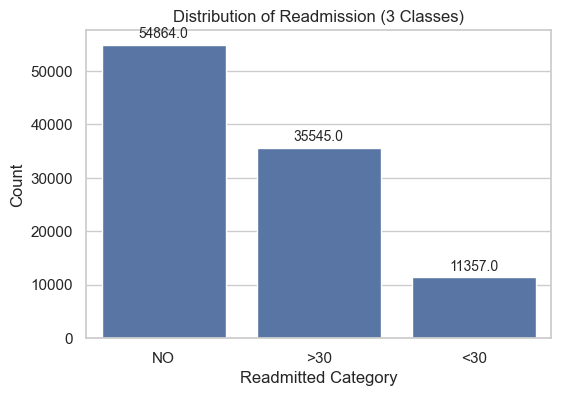

In [36]:
# We will use the 3 categories as our target
df['target'] = df['readmitted']

# Class counts and percentages
counts = df['target'].value_counts()
pcts = df['target'].value_counts(normalize=True) * 100
target_stats = pd.DataFrame({'Count': counts, 'Percentage (%)': pcts})
print(target_stats)

# Plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='target', order=['NO', '>30', '<30'])
plt.title('Distribution of Readmission (3 Classes)')
plt.xlabel('Readmitted Category')
plt.ylabel('Count')

# Annotate counts
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, xytext=(0, 5), textcoords='offset points')
plt.savefig('plots/EDA/target_distribution.png', bbox_inches='tight')
plt.show()



### What we learned
- The dataset is distributed across 3 classes: NO (~54%), >30 (~35%), and <30 (~11%).
- The class <30 (early readmission) is the minority class.

### What we will do about it
- We need to handle this as a multi-class classification problem predicting exactly these 3 categories.
- We must handle class imbalance during modeling since the `<30` class is much smaller than `NO` and `>30`.



## 3. Missing Values
We replace all string placeholders with NaN and calculate missingness across ALL columns.


                   Missing_Count  Missing_Pct
weight                     98569    96.858479
max_glu_serum              96420    94.746772
A1Cresult                  84748    83.277322
medical_specialty          49949    49.082208
payer_code                 40256    39.557416
race                        2273     2.233555
diag_3                      1423     1.398306
diag_2                       358     0.351787
diag_1                        21     0.020636
gender                         3     0.002948


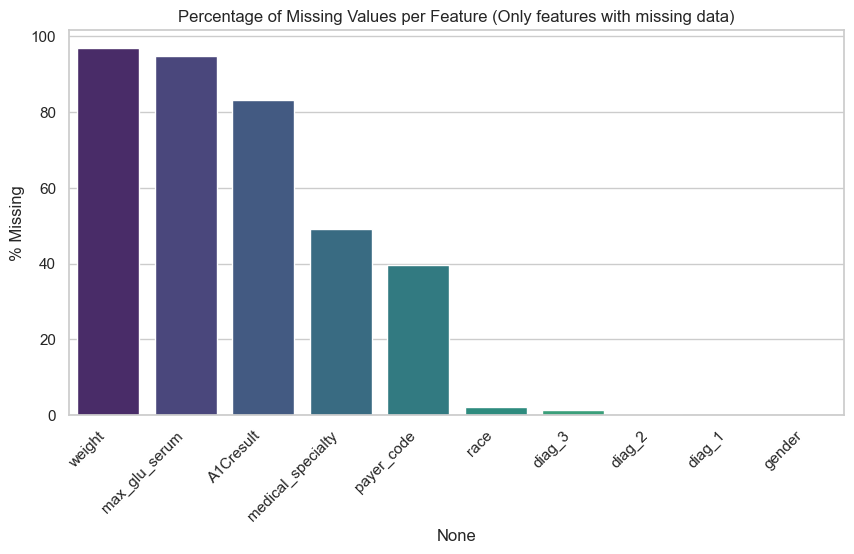

In [37]:
# Replace placeholders with NaN
placeholders = ['?', 'Unknown/Invalid', 'Not Available', 'NULL', 'Not Mapped']
df.replace(placeholders, np.nan, inplace=True)

# Calculate missing percentages for all features
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Pct': missing_pct})
missing_df = missing_df[missing_df['Missing_Pct'] > 0].sort_values(by='Missing_Pct', ascending=False)

print(missing_df)

# Plot
plt.figure(figsize=(10, 5))
if not missing_df.empty:
    sns.barplot(x=missing_df.index, y='Missing_Pct', data=missing_df, palette='viridis')
    plt.xticks(rotation=45, ha='right')
    plt.title('Percentage of Missing Values per Feature (Only features with missing data)')
    plt.ylabel('% Missing')
    plt.savefig('plots/EDA/missing_values.png', bbox_inches='tight')
    plt.show()
else:
    print("No missing values found after processing!")



### What we learned
- `weight` is missing in ~97% of the records.
- `medical_specialty` is missing ~49%.
- `payer_code` is missing ~39%.
- `race` and a few others have <5% missing values.

### What we will do about it
- **Drop** `weight` entirely due to excessive missingness.
- For `medical_specialty` and `payer_code`, we will fill with an `"Unknown"` category because the fact that it is missing might itself carry predictive information (e.g., lack of specialist access).
- For low-missingness columns like `race`, we will impute with the mode (most frequent) or drop those specific rows.



## 4. Duplicates & Patient Leakage Risk
Checking for identical rows and repeated encounters for the same patient.


Exact duplicate rows: 0
Unique patients: 71518 across 101766 total encounters.
Max encounters for a single patient: 40


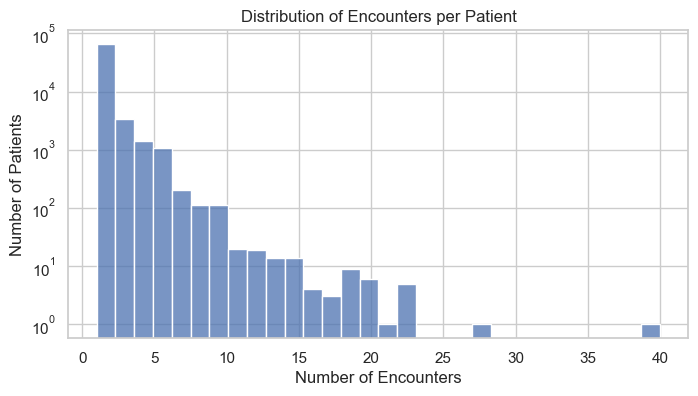

In [38]:
# Exact duplicate rows
print(f"Exact duplicate rows: {df.duplicated().sum()}")

# Patient encounters distribution
unique_patients = df['patient_nbr'].nunique()
print(f"Unique patients: {unique_patients} across {len(df)} total encounters.")

encounter_counts = df['patient_nbr'].value_counts()
print(f"Max encounters for a single patient: {encounter_counts.max()}")

plt.figure(figsize=(8, 4))
sns.histplot(encounter_counts, bins=30, kde=False)
plt.title('Distribution of Encounters per Patient')
plt.xlabel('Number of Encounters')
plt.ylabel('Number of Patients')
plt.yscale('log')
plt.savefig('plots/EDA/encounters_per_patient.png', bbox_inches='tight')
plt.show()



### What we learned
- There are no exact duplicate rows.
- However, there are ~71,518 unique patients for ~101,766 encounters, meaning tens of thousands of patients visit multiple times (up to 40 times!).

### What we will do about it
- We **must split the train/test sets by `patient_nbr`**, not randomly. Random splitting would cause data leakage. 
- We will likely extract only the first encounter per patient during preprocessing, or use GroupKFold.



## 5. Univariate Analysis
Let's explore the distribution of **ALL** numerical and categorical variables dynamically. We will plot every feature.


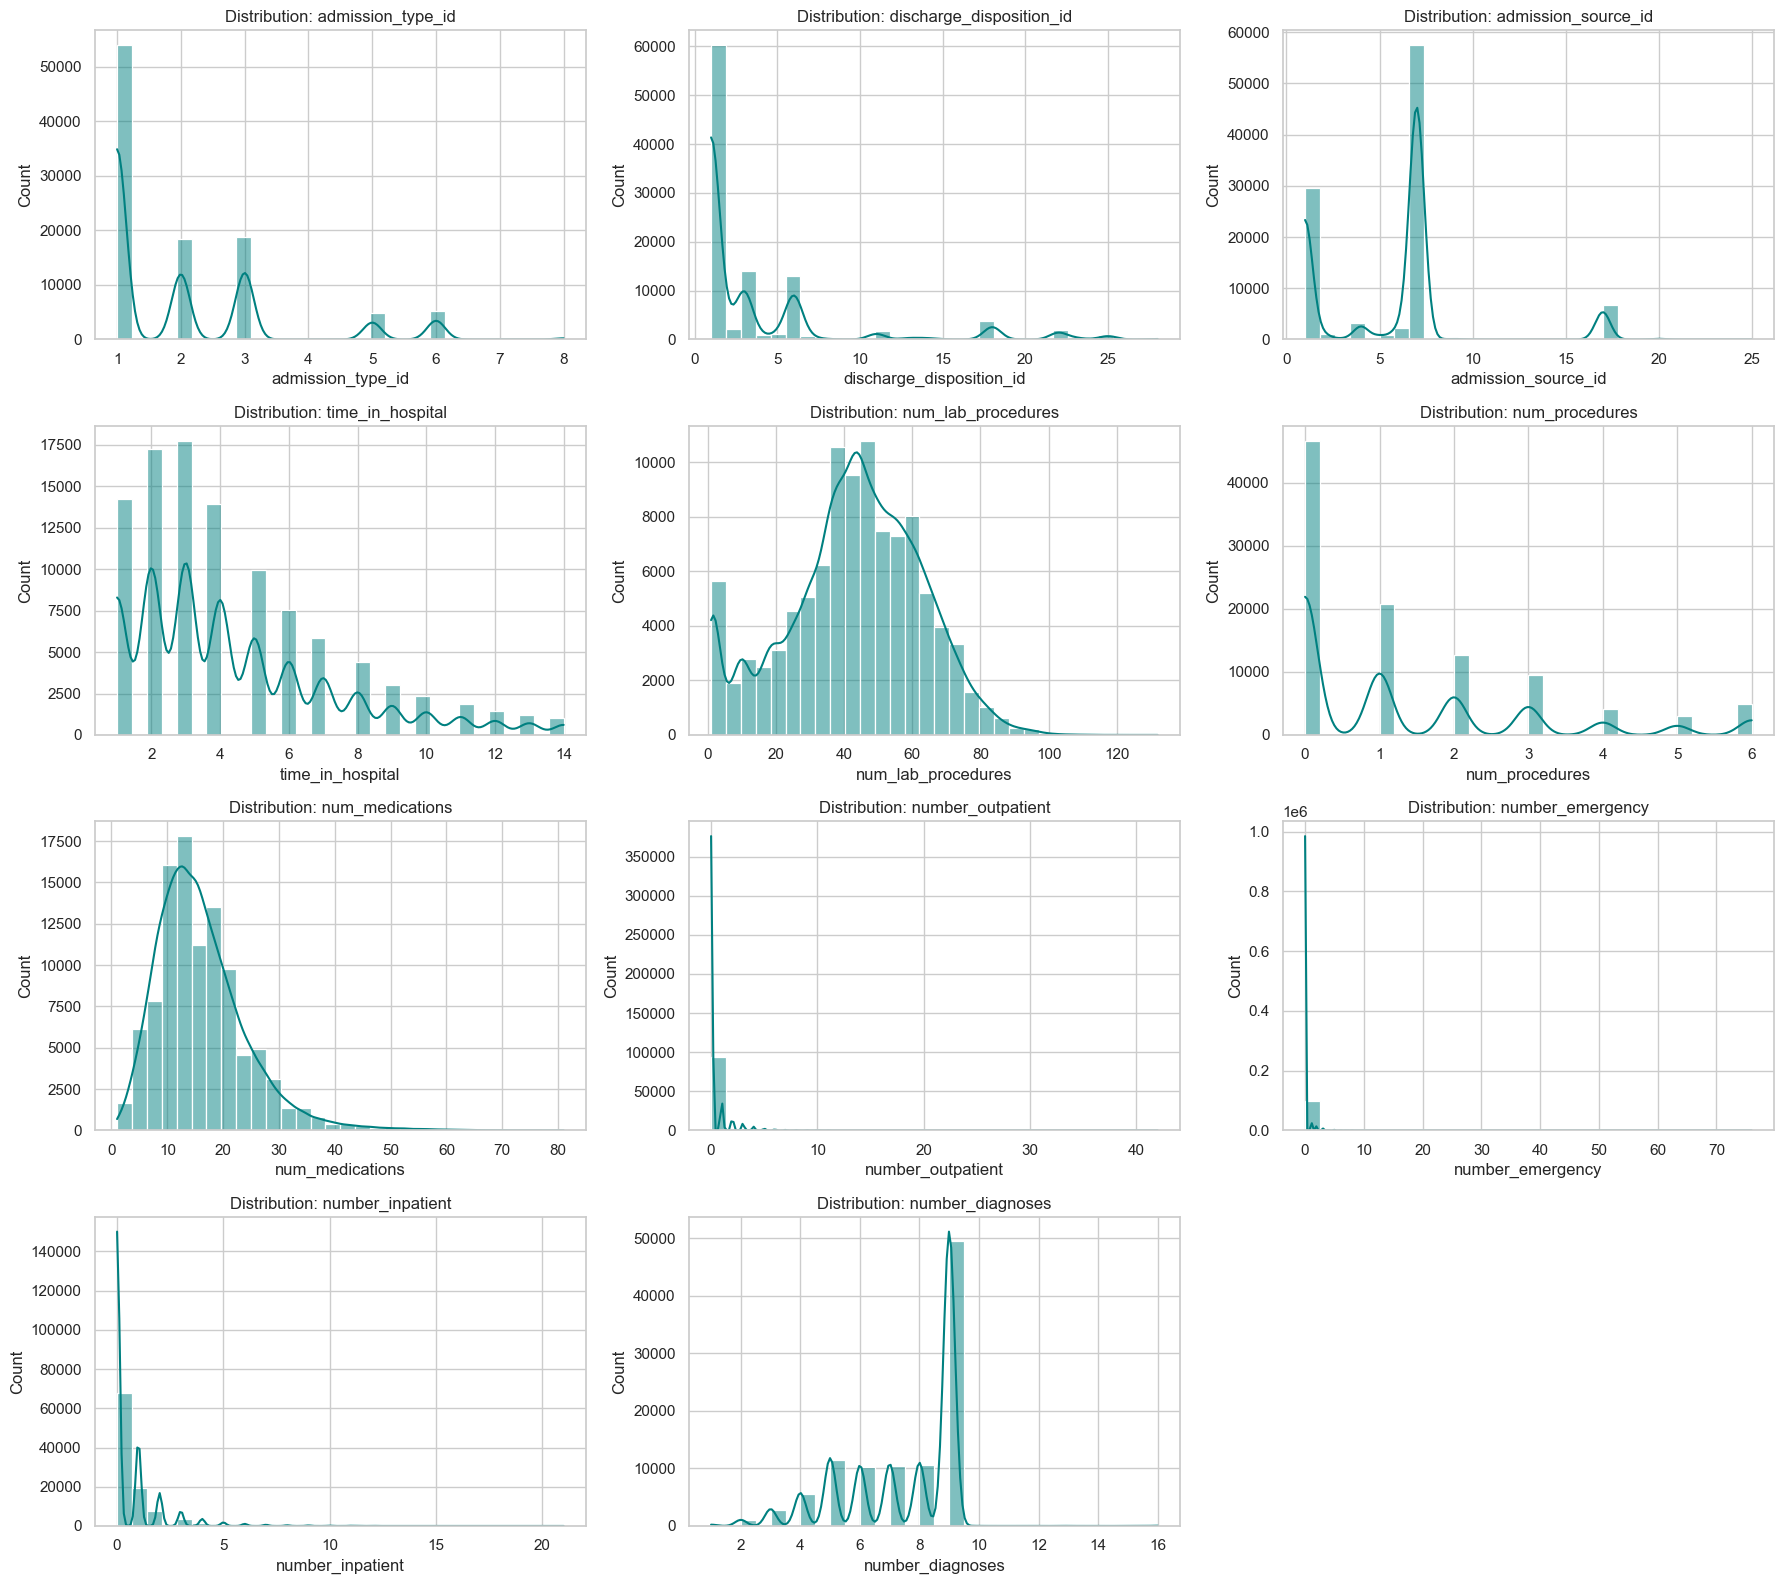


Numerical Statistics & Outliers:
                             count       mean        std  min   25%   50%  \
admission_type_id         101766.0   2.024006   1.445403  1.0   1.0   1.0   
discharge_disposition_id  101766.0   3.715642   5.280166  1.0   1.0   1.0   
admission_source_id       101766.0   5.754437   4.064081  1.0   1.0   7.0   
time_in_hospital          101766.0   4.395987   2.985108  1.0   2.0   4.0   
num_lab_procedures        101766.0  43.095641  19.674362  1.0  31.0  44.0   
num_procedures            101766.0   1.339730   1.705807  0.0   0.0   1.0   
num_medications           101766.0  16.021844   8.127566  1.0  10.0  15.0   
number_outpatient         101766.0   0.369357   1.267265  0.0   0.0   0.0   
number_emergency          101766.0   0.197836   0.930472  0.0   0.0   0.0   
number_inpatient          101766.0   0.635566   1.262863  0.0   0.0   0.0   
number_diagnoses          101766.0   7.422607   1.933600  1.0   6.0   8.0   

                           75%    max   s

In [39]:
# Plot ALL Numerical features
num_cols_count = len(numeric_cols)
rows = math.ceil(num_cols_count / 3)
fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution: {col}')

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/EDA/univariate_numerical.png', bbox_inches='tight')
plt.show()

# Stats
stats_df = df[numeric_cols].describe().T
stats_df['skewness'] = df[numeric_cols].skew()

# IQR Outlier Detection
outliers_list = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_list.append(outliers_count)
    
stats_df['outliers (IQR)'] = outliers_list
print("\nNumerical Statistics & Outliers:")
print(stats_df)



### Outlier Visualization (Boxplots)
To visually inspect the outliers detected by the IQR method above, we plot boxplots for all numerical features.


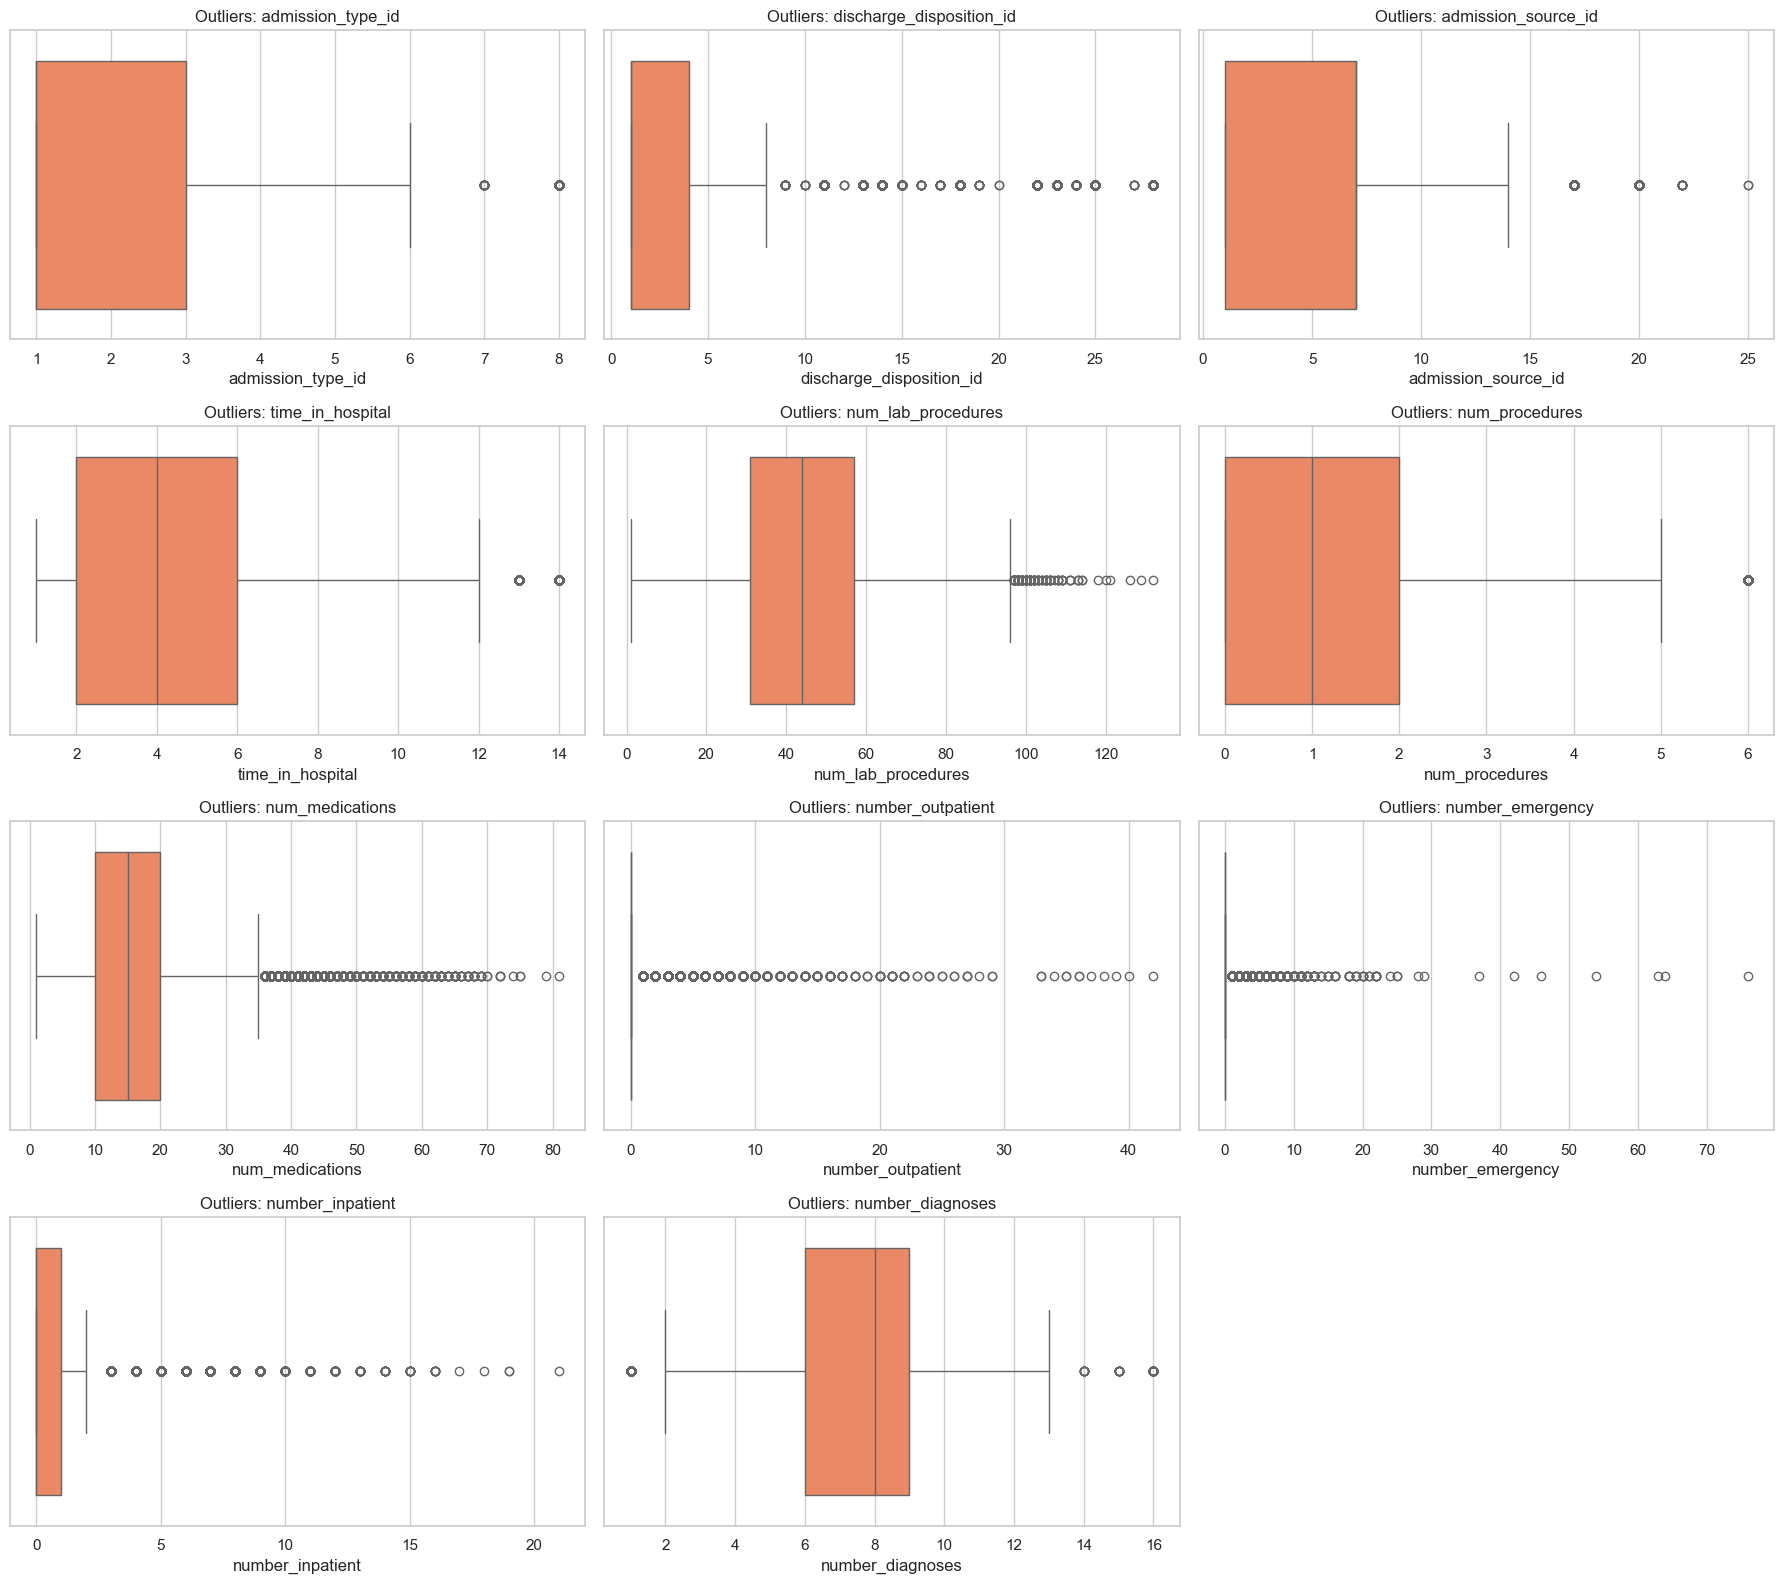

In [40]:
# Boxplots for numerical outliers
fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='coral')
    axes[i].set_title(f'Outliers: {col}')

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/EDA/outliers_boxplots.png', bbox_inches='tight')
plt.show()



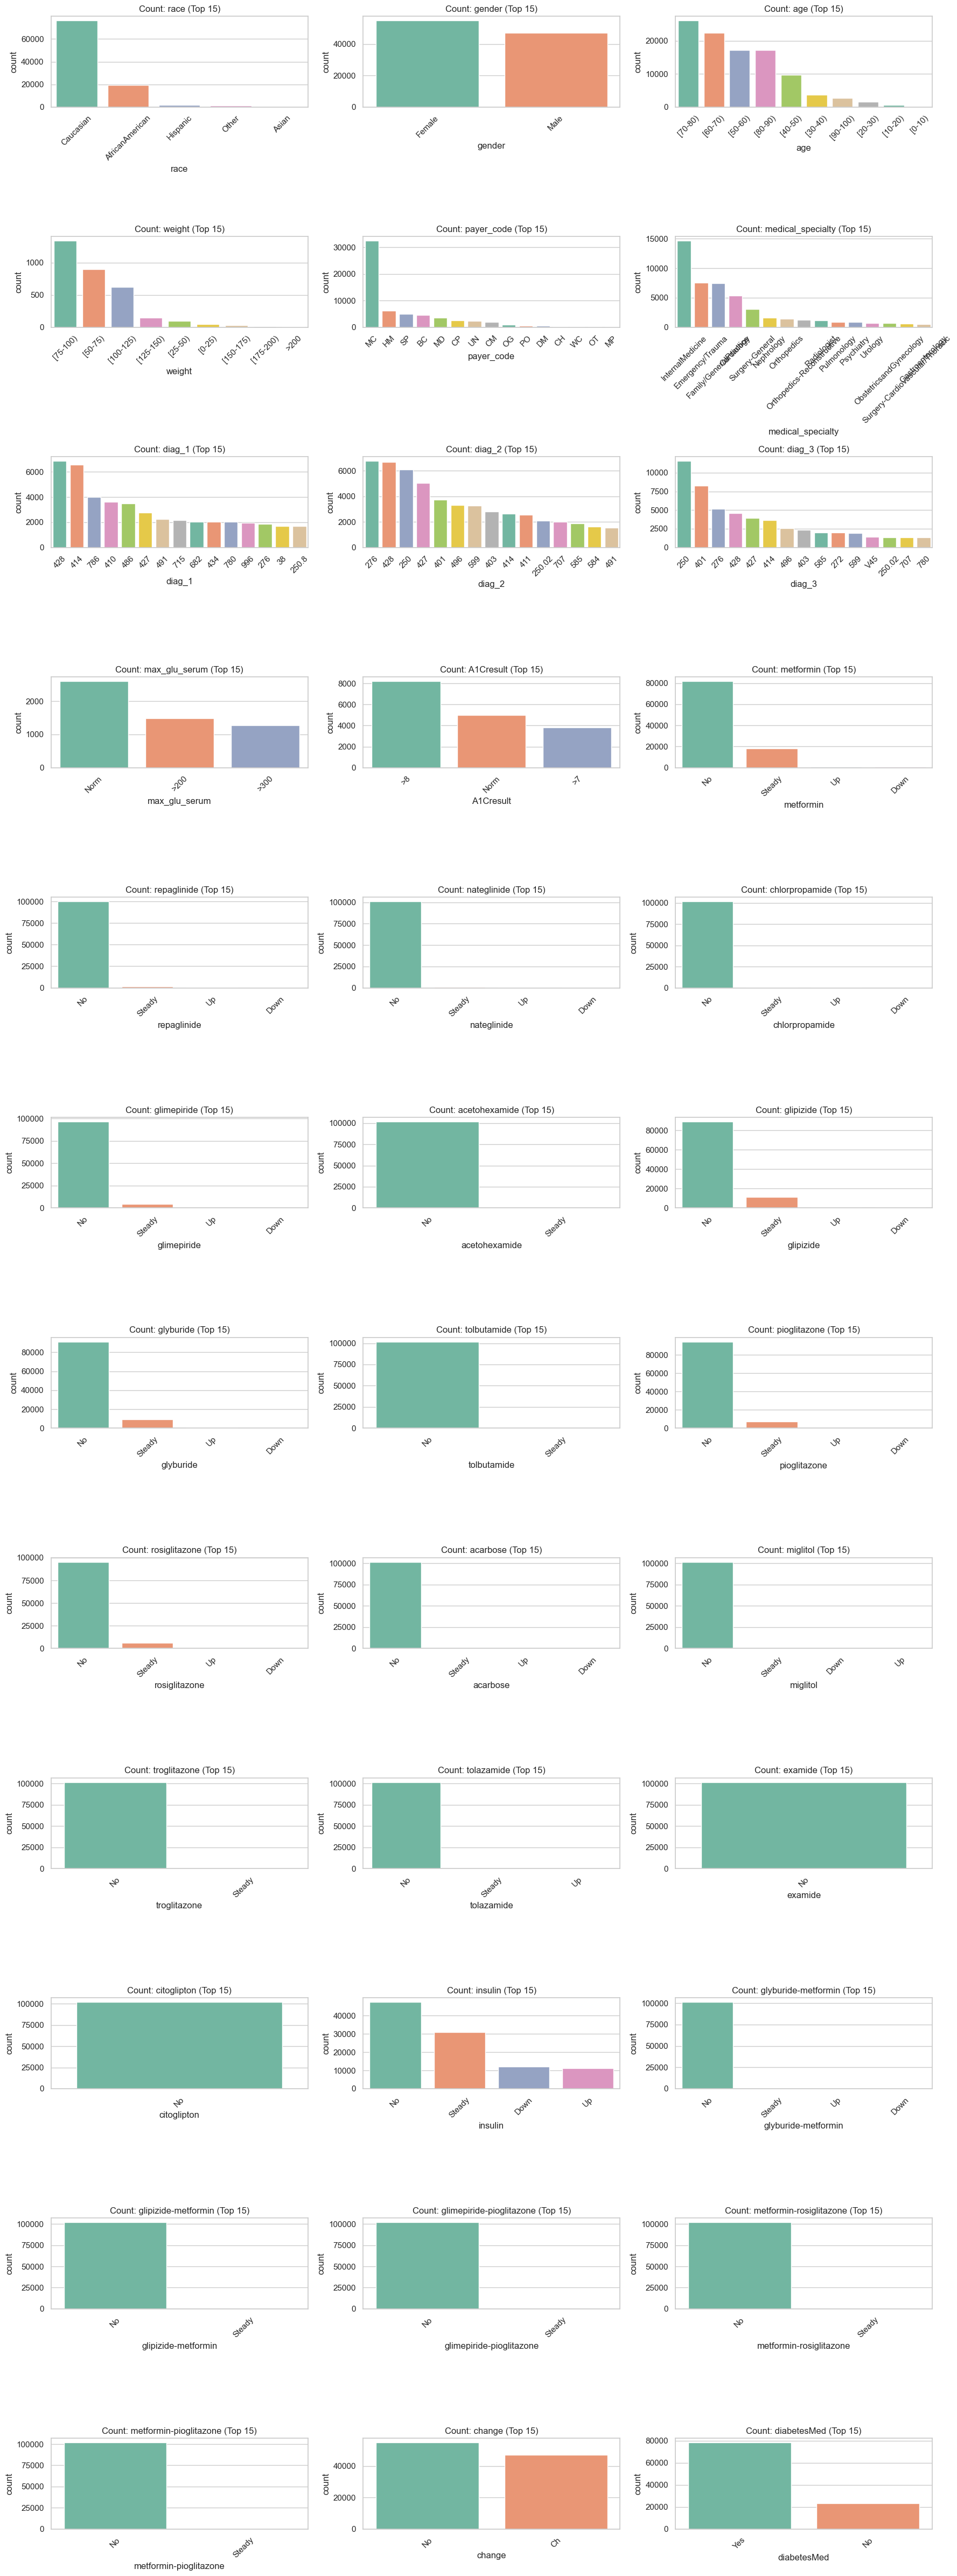

In [41]:
# Plot ALL Categorical features
# Note: For high cardinality features like diagnoses (diag_1, diag_2, diag_3), we only plot the top 15 categories to keep it readable.
cat_cols_count = len(categorical_cols)
rows = math.ceil(cat_cols_count / 3)
fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Get top 15 categories if there are too many unique values
    top_cats = df[col].value_counts().nlargest(15).index
    sns.countplot(data=df[df[col].isin(top_cats)], x=col, ax=axes[i], palette='Set2', order=top_cats)
    axes[i].set_title(f'Count: {col} (Top 15)')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/EDA/univariate_categorical.png', bbox_inches='tight')
plt.show()



### What we learned
- Count-based numerical variables (`number_emergency`, `number_inpatient`) are heavily right-skewed with most values at 0.
- `time_in_hospital` and `num_lab_procedures` follow somewhat skewed normal distributions.
- Dozens of medication columns (like `chlorpropamide`, `tolbutamide`) are overwhelmingly heavily imbalanced, where >99% of patients have "No" (not prescribed).
- The ICD-9 diagnosis codes (`diag_1`, `diag_2`, `diag_3`) have hundreds of unique values.

### What we will do about it
- We will consider applying log transformations to highly skewed numerical features.
- We should drop medication features that have close to zero variance (e.g., 99.9% "No") as they offer no predictive power.
- Diagnosis codes must be grouped (e.g., grouping by disease category like Circulatory, Respiratory) rather than one-hot encoding hundreds of unique codes.



## 6. Feature vs Target (Readmission Risk)
We analyze how **ALL** features correlate with the 3 target classes using stacked bar charts.


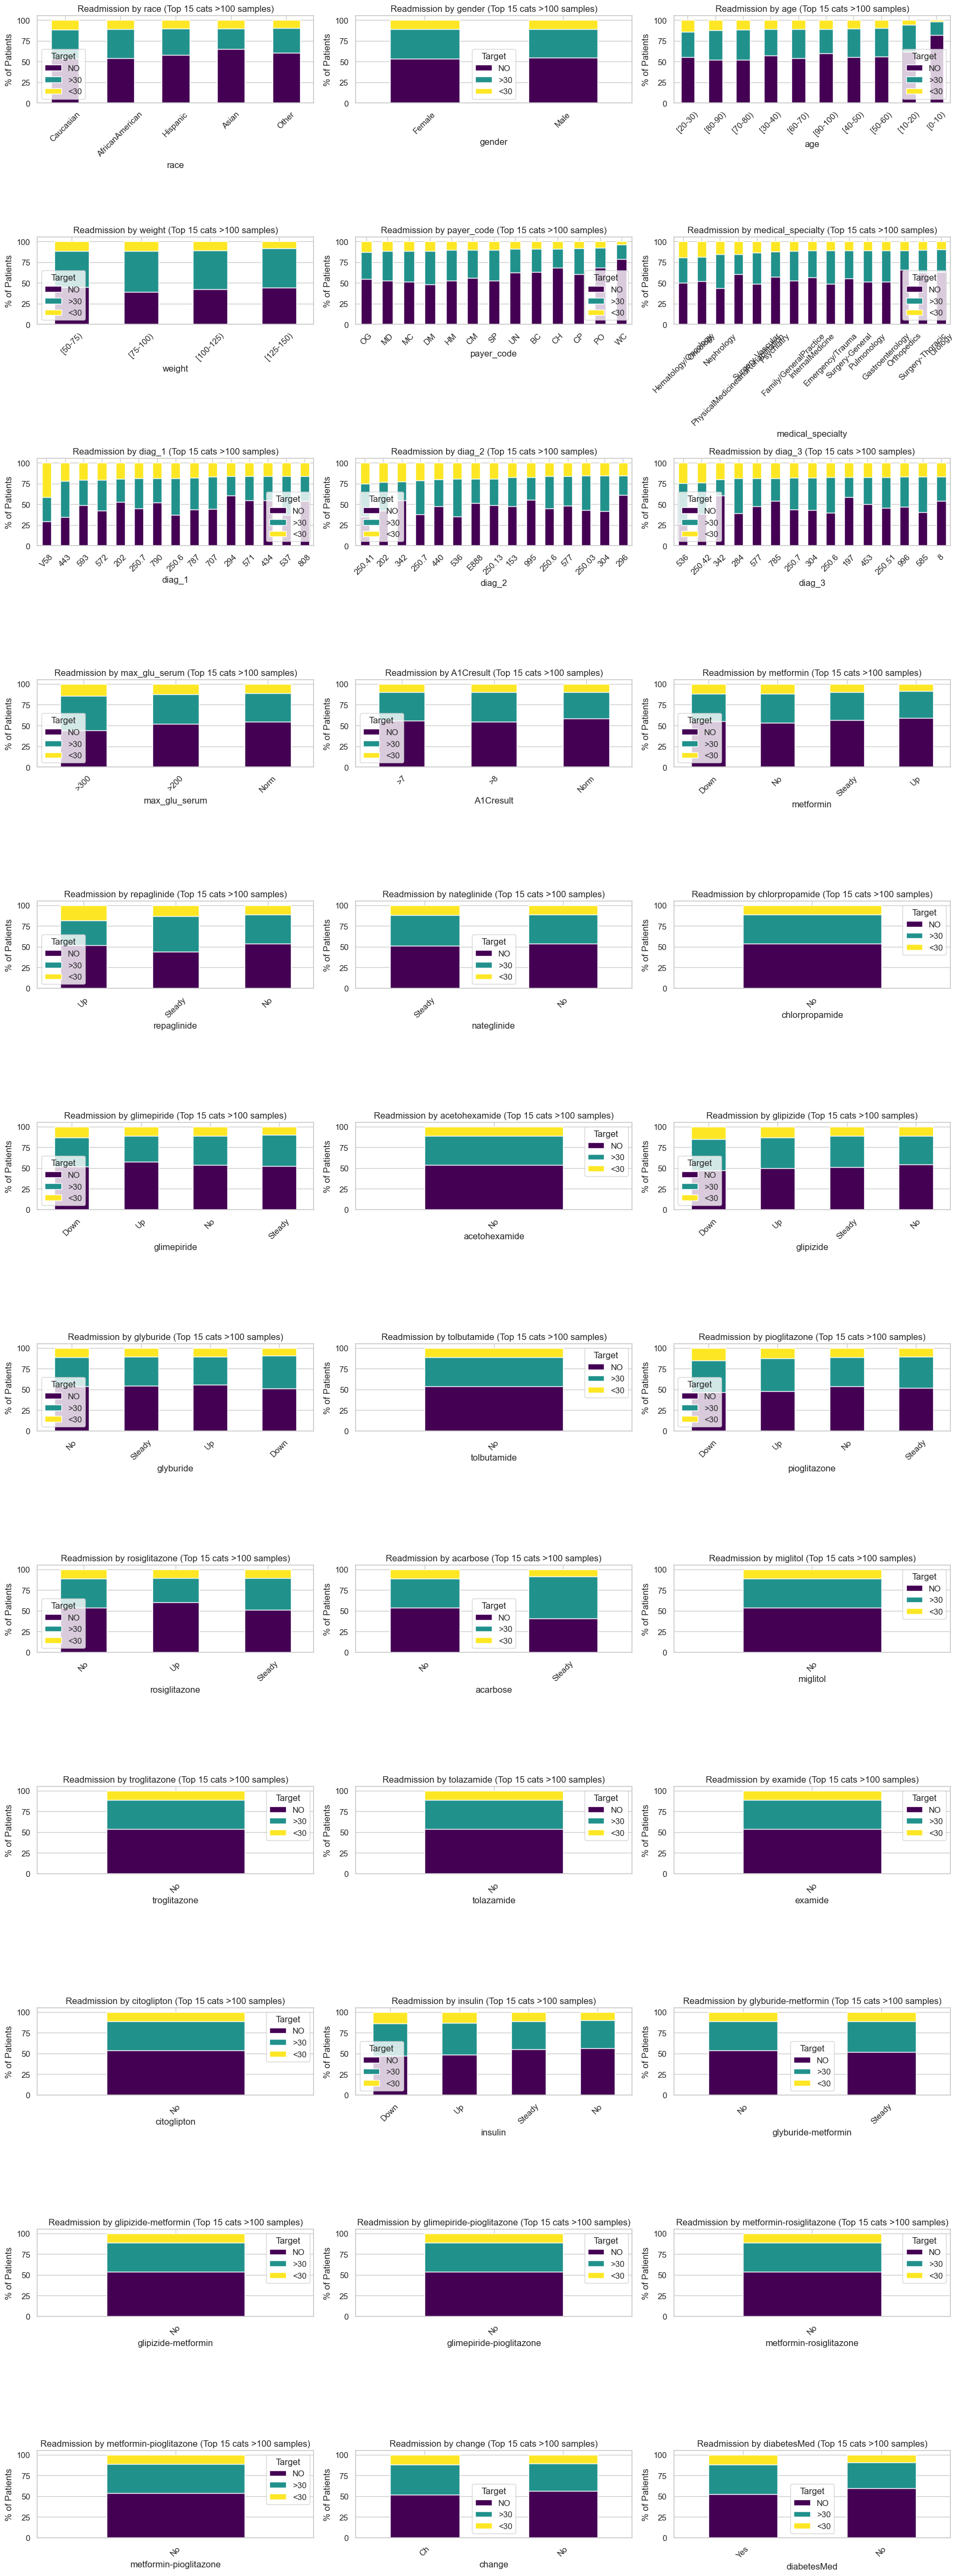

In [42]:
def plot_readmission_distribution(col, ax):
    # Cross tabulation of the feature vs target
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    
    # Only show categories with more than 100 samples to avoid extreme noise from small groups
    counts = df[col].value_counts()
    valid_cats = counts[counts > 100].index
    
    if len(valid_cats) == 0:
        return # Skip if no categories have enough data
        
    ct = ct.loc[valid_cats]
    
    # Sort by the critical '<30' class if it exists
    if '<30' in ct.columns:
        ct = ct.sort_values(by='<30', ascending=False)
        
    # Plot top 15 max to keep it readable
    ct = ct.head(15)
        
    ct[['NO', '>30', '<30']].plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
    ax.set_title(f'Readmission by {col} (Top 15 cats >100 samples)')
    ax.set_ylabel('% of Patients')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Target')

# Plot for ALL categorical features
fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    plot_readmission_distribution(col, axes[i])

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/EDA/feature_vs_target_categorical.png', bbox_inches='tight')
plt.show()



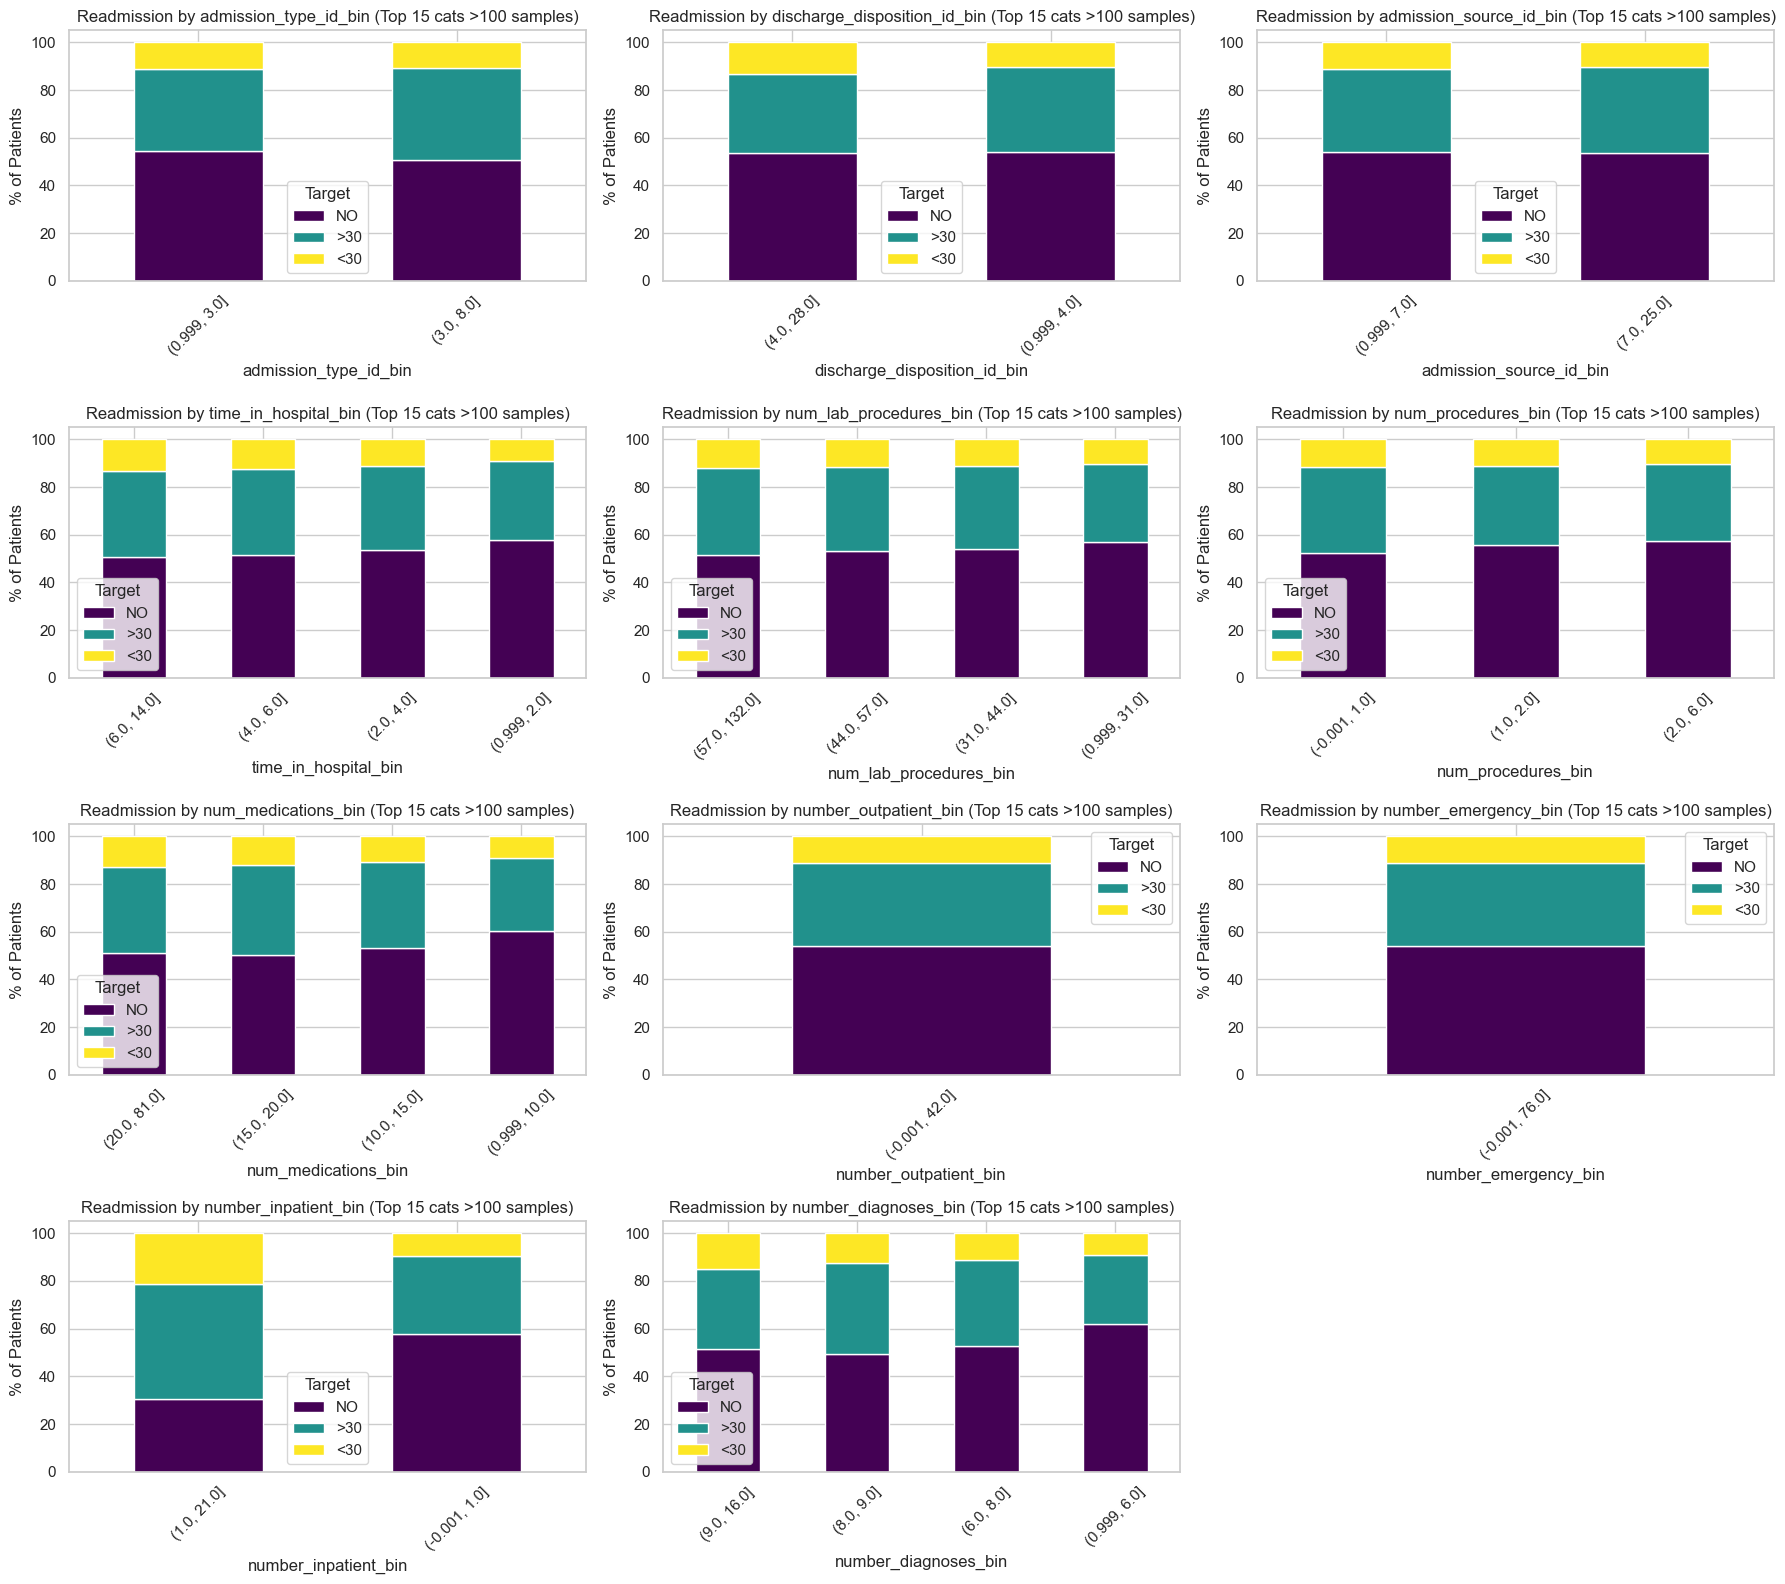

In [43]:
# Plot for ALL numerical features (by binning them)
num_rows = math.ceil(num_cols_count / 3)
fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Create 4 quantile bins for the numerical feature
    bin_col = f'{col}_bin'
    try:
        df[bin_col] = pd.qcut(df[col], q=4, duplicates='drop')
        plot_readmission_distribution(bin_col, axes[i])
    except ValueError:
        # If qcut fails (e.g. too many zeros), use regular cut
        df[bin_col] = pd.cut(df[col], bins=4)
        plot_readmission_distribution(bin_col, axes[i])

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/EDA/feature_vs_target_numerical.png', bbox_inches='tight')
plt.show()



### What we learned
- Across almost all features, the proportion of `<30` and `>30` fluctuates.
- Certain `discharge_disposition_id` codes have very high readmission rates.
- Patients with higher `number_inpatient` (previous inpatient visits) have noticeably higher proportions of early readmission (`<30`).
- Medication changes (`change` = "Ch") slightly increase the likelihood of readmission.

### What we will do about it
- `number_inpatient` will likely be a very strong predictive feature.
- We will group similar discharge disposition codes and admission source codes to strengthen the signal for the models.



## 7. Feature Relationships
Checking for multicollinearity amongst ALL numerical features.


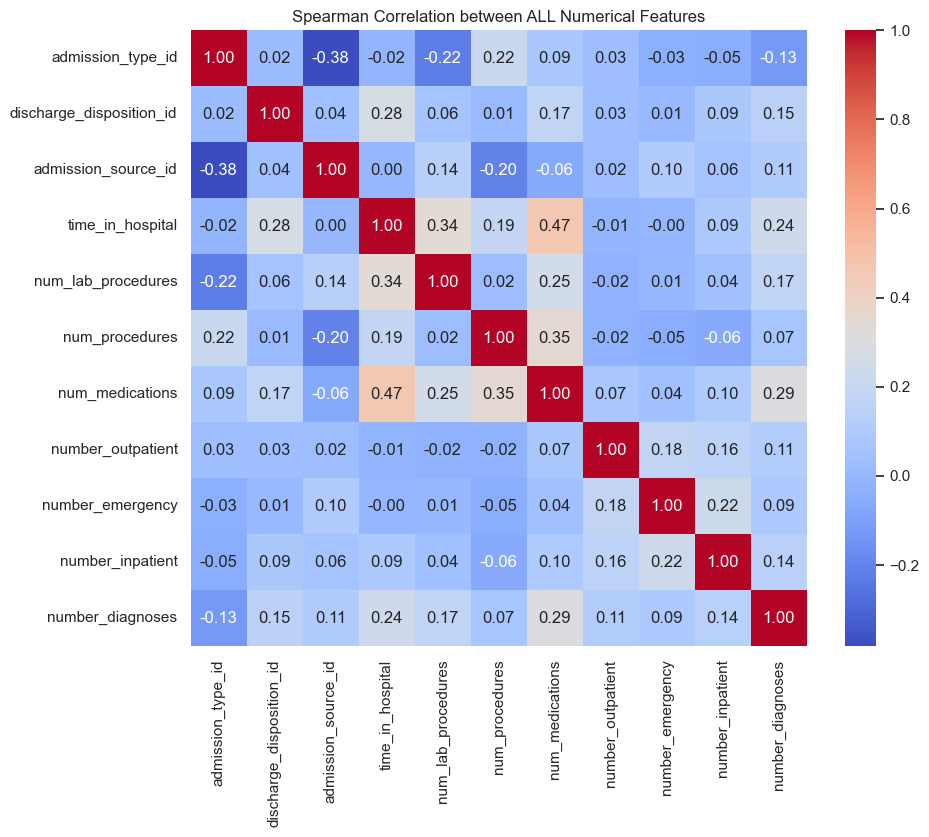

In [44]:
# Correlation heatmap
corr = df[numeric_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Spearman Correlation between ALL Numerical Features')
plt.savefig('plots/EDA/correlation_heatmap.png', bbox_inches='tight')
plt.show()



### What we learned
- `num_medications` and `time_in_hospital` are positively correlated (0.47).
- `num_medications` and `num_procedures` also have positive correlation (0.39).
- Overall, there is no severe multicollinearity (no correlations > 0.8).

### What we will do about it
- We don't need to aggressively drop numerical features due to multicollinearity. All of them can be retained for the tree-based models.



## 8. Data Quality & Conceptual Leakage
Certain patients (e.g., deceased or transferred to hospice) conceptually cannot be readmitted. Including them can bias the model.


In [45]:
# Check discharge_disposition_id for expired/hospice patients
# Codes 11, 13, 14, 19, 20, 21 represent death or hospice
terminal_codes = [11, 13, 14, 19, 20, 21]
terminal_patients = df[df['discharge_disposition_id'].isin(terminal_codes)]

print(f"Patients discharged to hospice or expired: {len(terminal_patients)}")



Patients discharged to hospice or expired: 2423


### What we learned
- Thousands of patients were discharged to hospice or expired.
- These patients are virtually guaranteed not to be readmitted, meaning they are "easy" negatives that artificially inflate model performance for the 'NO' class.

### What we will do about it
- We will **drop** all rows with these discharge disposition codes during preprocessing to ensure the model focuses on patients who actually *could* be readmitted.



## 9. EDA Conclusions & Next Steps
We have a clear path forward for the Preprocessing phase.

| Finding | Implication | Action |
| :--- | :--- | :--- |
| `weight` has 97% missing data | Unusable feature | Drop column |
| Near-zero variance on many medications | No predictive power | Drop columns with >99% 'No' |
| Multi-class imbalance | Accuracy is a bad metric | Use SMOTE/class weights |
| High encounters per patient | Random split causes leakage | GroupKFold / Split by `patient_nbr` |
| Hospice/Death discharge codes | Inflates negative classes | Drop rows with terminal codes |
| Diagnosis codes have 700+ unique values | High dimensionality | Group ICD-9 codes by category |

